In [1]:
import anndata as ad
from genome_tools.data.anndata import read_zarr_backed
import pandas as pd
import scipy.sparse as sp
import numpy as np
import warnings
from tqdm import tqdm
from collections import defaultdict
from genome_tools import GenomicInterval, VariantInterval

In [8]:
variants = pd.read_parquet('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/non_aggregated.extended_annotation.parquet')

In [2]:
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [10]:
# variants

In [10]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
variants["indiv_id"] = (
    variants["sample_id"].map(indiv_id_mapping["indiv_id"]).fillna("").astype(str)
)

In [11]:
variants["total_counts"] = variants.ref_counts + variants.alt_counts


In [11]:
passed_read_count = (variants.total_counts > 20) & (variants.ref_counts > 0) & (variants.alt_counts > 0)
# signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
# neg = variants.FDR_sample > 0.5

# positives = variants[passed_read_count & signif]
# negatives = variants[passed_read_count & neg].sample(n=len(positives))

# examples = pd.concat([positives, negatives])
# #this doesnt work because its the genotype that has duplicates
# examples = examples.groupby(["#chr", "start", "ref", "sample_id"]).filter(lambda x: len(x)==1)

In [12]:
import matplotlib.pyplot as plt
# bins = np.linspace(-5, 5, 100)
# h = plt.hist(positives.logit_es, bins=bins)
# h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
# plt.xlabel("LFC variant effect")

In [13]:
variants_filtered = variants.loc[passed_read_count].copy()


In [15]:
#running one for all no filter
# variants_filtered=variants

In [14]:
variants_filtered.shape

(16433862, 88)

In [3]:
key_cols = ["#chr", "start", "end","ref", "alt", "indiv_id","sample_id"]

variants_no_duplicate = variants_filtered.drop_duplicates(subset=key_cols, keep=False)

NameError: name 'variants_filtered' is not defined

In [ ]:
variants_no_duplicate

In [ ]:
key_cols = ["#chr", "start", "end", "indiv_id"]

# Count unique allele combinations per individual per position
allele_counts = (
    variants_no_duplicate
    .groupby(key_cols)[["ref", "alt"]]
    .nunique()
)

# positions where ref or alt varies (multi-allelic)
multi_mask = (allele_counts["ref"] > 1) | (allele_counts["alt"] > 1)

multi_sites = allele_counts[multi_mask].index

# Remove those rows
variants_no_multiple = variants_no_duplicate[
    ~variants_no_duplicate.set_index(key_cols).index.isin(multi_sites)
].reset_index(drop=True)

In [ ]:
variants_no_multiple.head()

In [ ]:
variants_no_multiple.shape

In [ ]:
#remove duplicates from genotype file
gtfile = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz'
genotype_df=pd.read_csv(gtfile,sep='\t',compression='gzip')

In [24]:
#remove duplicates
multi = (
    genotype_df
    .groupby(["#chr", "start", "sample"])[["ref", "alt"]]
    .nunique()
)

multi = multi[(multi["ref"] > 1) | (multi["alt"] > 1)]

In [25]:
multi_sites = multi.reset_index()[["#chr", "start", "sample"]]

In [28]:
genotype_df.shape

(114858154, 8)

In [26]:
genotype_clean = genotype_df.merge(
    multi_sites,
    on=["#chr", "start", "sample"],
    how="left",
    indicator=True
)

genotype_clean = genotype_clean[genotype_clean["_merge"] == "left_only"]
genotype_clean = genotype_clean.drop(columns="_merge")

In [27]:
genotype_clean

,#chr,start,end,ref,alt,sample,genotype,phase_set
0,chr1,792861,792862,C,G,INDIV_0001,1/1,.
1,chr1,792861,792862,C,G,INDIV_0003,1/1,.
2,chr1,792861,792862,C,G,INDIV_0004,1/1,.
3,chr1,792861,792862,C,G,INDIV_0008,1/1,.
4,chr1,792861,792862,C,G,INDIV_0079,0/1,.
...,...,...,...,...,...,...,...,...
114858149,chrEBV,169328,169329,G,C,INDIV_0115,1/1,.
114858150,chrEBV,169370,169371,T,C,INDIV_0115,1/1,.
114858151,chrEBV,169410,169411,T,C,INDIV_0115,1/1,.
114858152,chrEBV,169432,169433,C,T,INDIV_0115,1/1,.


In [32]:
#save genotype without multiallelic
genotype_clean.to_csv(
    "/home/mbrannon/genotype_no_multiallelic.tsv",
    sep="\t",
    index=False,
)

NameError: name 'genotype_clean' is not defined

In [ ]:
#save genotype without multiallelic
genotype_clean = pd.read_csv(
    "/home/mbrannon/genotype_no_multiallelic.tsv",
    sep="\t",
    index=False,
)

In [ ]:
genotype_clean

#need to do this before train
bgzip /home/mbrannon/genotype_no_multiallelic.tsv
tabix -s 1 -b 2 -e 3 /home/mbrannon/genotype_no_multiallelic.tsv.gz

In [ ]:
variants_filtered = variants_no_multiple

In [33]:
passed_read_count = (variants_filtered.total_counts > 20) & (variants_filtered.ref_counts > 0) & (variants_filtered.alt_counts > 0)
signif = (variants_filtered.FDR_sample < 0.1) & (variants_filtered.logit_es.abs() < 6)
neg = variants_filtered.FDR_sample > 0.5

positives = variants_filtered[passed_read_count & signif]
# negatives = variants_filtered[passed_read_count & neg].sample(n=len(positives))

# examples = pd.concat([positives, negatives])
# #this doesnt work because its the genotype that has duplicates
# examples = examples.groupby(["#chr", "start", "ref", "sample_id"]).filter(lambda x: len(x)==1)

In [34]:
len(positives)


392275

In [35]:
len(neg)

16433862

In [36]:
variants_no_multiplie['variant_id'] = variants_no_multiple['#chr'] + ":" + variants_no_multiple['end'].astype(str) + ':' + variants_no_multiple['ref'] + ':' + variants_no_multiple['alt']


In [38]:
#create adata parquet
meta = pd.read_table(
    '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/metadata.clustered.tsv',
    usecols=['sample_id', 'extended_annotation']
).drop_duplicates()

In [39]:
variants_no_multiple = variants_no_multiple.rename(columns={'group_id': 'badgroup'})

In [40]:
cavs = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/output/differential_pvals.extended_annotation.bed'

In [41]:
cavs_df = pd.read_table(cavs)

In [42]:
variants_no_multi = variants_no_multiple.merge(
    meta,
    on="sample_id",
    how="left"
)

# Replace group_id with extended_annotation
variants_no_multi["group_id"] = variants_no_multi["extended_annotation"]

# (optional) drop the helper column
variants_no_multi = variants_no_multi.drop(columns=["extended_annotation"])

In [43]:
variants_no_multi

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,FDR_sample,hotspots,footprints,peaks,inverse_mse,badgroup,indiv_id,total_counts,variant_id,group_id
0,chr1,804903,804904,rs61770167,C,T,10,17,AG72382,0.004093,...,0.848497,0,-,0,12.792043,B-cell,INDIV_0120,27,chr1:804904:C:T,B-cell
1,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,0.937686,0,-,0,14.564382,group_id,INDIV_0120,35,chr1:804904:C:T,B-cell
2,chr1,811013,811014,rs3925105,G,A,16,7,AG80695,0.219092,...,1.000000,0,-,0,8.899708,group_id,INDIV_0130,23,chr1:811014:G:A,Myoblast
3,chr1,814809,814810,rs573971885,C,T,17,8,AG92965,0.013961,...,0.929859,0,-,0,9.020596,B-cell,INDIV_0063,25,chr1:814810:C:T,B-cell
4,chr1,816320,816321,rs1292241435,A,G,17,10,AG80304,0.000008,...,0.974179,0,-,0,6.487607,Basal ganglia,INDIV_0094,27,chr1:816321:A:G,Basal ganglia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16433751,chr9,138217445,138217446,rs11562371,C,T,26,13,AG80357,0.370349,...,1.000000,0,-,0,9.527468,Epithelium,INDIV_0070,39,chr9:138217446:C:T,Epithelium
16433752,chr9,138217445,138217446,rs11562371,C,T,26,16,AG10147,0.370349,...,1.000000,0,-,0,9.592975,CML,INDIV_0002,42,chr9:138217446:C:T,CML
16433753,chr9,138217445,138217446,rs11562371,C,T,8,13,AG6935,0.370349,...,0.969241,0,-,0,11.281521,Pluripotent/Pluripotent-derived,INDIV_0012,21,chr9:138217446:C:T,Pluripotent/Pluripotent-derived
16433754,chr9,138219528,138219529,rs11791069,T,A,21,4,AG72741,0.239058,...,0.994950,0,-,0,9.020596,Monocyte,INDIV_0421,25,chr9:138219529:T:A,Monocyte


In [44]:
# Columns to keep from cavs_df
cavs_keep_cols = [
    'ID', 'group_id', 'group_es', 'group_es_std', 'indivs_count',
    'samples_count', 'p_differential', 'cell_selective', 'n_groups',
    'group_es_var', 'mean_group_mse', 'es_combined', 'overall_imbalanced',
    'logit_es_combined', 'fdr_group', 'signif_max_es', 'signif_min_es',
    'concordant', 'discordant', 'logit_group_es'
]

# Subset cavs_df
cavs_subset = cavs_df[cavs_keep_cols]
cavs_subset = cavs_subset.drop_duplicates(subset=["ID", "group_id"])


merged_df = variants_no_multi.merge(
    cavs_subset,
    how="left",
    on=["ID", "group_id"],
    suffixes=("", "_cavs")
)


In [45]:
used_results=merged_df
float_cols = [
    'group_es', 'group_es_std', 'logit_group_es',
    'group_es_var', 'mean_group_mse',
    'signif_max_es', 'signif_min_es'
]

used_results[float_cols] = used_results[float_cols].astype('float32')


In [46]:
def get_category(per_variant, aggregation_fdr=0.1):
    ########## Convert float -> bool #############
    bool_cols = ['discordant', 'concordant', 'cell_selective', 'overall_imbalanced']
    for col in bool_cols:
        if col in per_variant.columns:
            per_variant[col] = per_variant[col].fillna(0).astype(bool)
    order = ['not_cell_selective', 
             'concordant_and_overall', 
             'discordant_and_overall', 
             'discordant', 
             'concordant',  
             'weak_cell_selective',
             'not_imbalanced']
    
    per_variant['category'] = np.select(
        [
            per_variant.eval('discordant & overall_imbalanced').fillna(False),
            per_variant.eval('discordant & ~overall_imbalanced').fillna(False),
            per_variant.eval('concordant & overall_imbalanced').fillna(False),
            per_variant.eval('concordant & ~overall_imbalanced').fillna(False),
            per_variant['cell_selective'],
            per_variant['overall_imbalanced'],
            ~per_variant['overall_imbalanced']                        
        ], 
        [
            'discordant_and_overall',
            'discordant',
            'concordant_and_overall',
            'concordant',
            'weak_cell_selective',
            'not_cell_selective',
            'not_imbalanced',
        ],
        default='wtf'
    )
    
    per_variant['category'] = pd.Categorical(per_variant['category'], categories=order, ordered=True)

    ########## Core category #############
    core_order = ['weak_cell_selective', 'concordant', 'discordant', 'not_cell_selective', 'not_imbalanced']
    
    per_variant['core_category'] = np.select(
        [
            per_variant['category'].isin(['discordant_and_overall', 'discordant']),
            per_variant['category'].isin(['concordant_and_overall', 'concordant'])
        ],
        [
            'discordant',
            'concordant'
        ],
        per_variant['category']
    )
    
    per_variant['core_category'] = pd.Categorical(per_variant['core_category'], categories=core_order, ordered=True)
    return per_variant

used_results = get_category(used_results)

# Adding a bunch of columns. Majority are redundant and needed for tests only. Need to cleanup
category_colors = dict(zip(
    used_results['core_category'].cat.categories,
    [
        '#fcde9c',
        '#7ccba2',
        '#f0746e',
        '#dc3977',
        '#089099',
        '#838383',
        '#C3C3C3',
    ]
))

category_labels = dict(zip(
    used_results['category'].cat.categories,
    [
        'Context independent',
        'Concordant and overall imbalanced',
        'Discordant and overall imbalanced',
        'Discordant',
        'Concordant',
        'Weak context dependent',
        'Not imbalanced',
    ]
))

In [47]:
def logit_es(es, d=1/128):
    return np.log2(es + d) - np.log2(1 - es + d)

def logit_es_prime(es, d=1/128):
    return (2 * d + 1) / ((es + d) * (1 - es + d) * np.log(2))

In [48]:
# --- Median number of samples per variant ---
used_results['med_num_samples'] = used_results.groupby('variant_id')['samples_count'].transform(np.median)

# --- Full group std ---
used_results['full_group_std'] = np.sqrt(used_results['mean_group_mse'] + used_results['group_es_var'])

# --- Z-scores ---
used_results['z'] = (used_results['group_es'] - 0.5) / used_results['full_group_std']

# --- Significant z (FDR < 0.1) ---
used_results['signif_z'] = np.where(used_results['fdr_group'] < 0.1, used_results['z'], 0)

# --- Max/Min z per variant ---
used_results['max_z'] = used_results.groupby('variant_id')['signif_z'].transform('max')
used_results['min_z'] = used_results.groupby('variant_id')['signif_z'].transform('min')

# --- Discordance scores ---
used_results['min_abs_z'] = np.minimum(np.abs(used_results['max_z']), np.abs(used_results['min_z']))
used_results['discordance_score'] = used_results['min_abs_z'] * (((used_results['max_z'] * used_results['min_z']) < 0) * 2 - 1)
used_results['max_z_score'] = np.maximum(np.abs(used_results['max_z']), np.abs(used_results['min_z']))
used_results['diff_z_score'] = np.abs(used_results['max_z']) - np.abs(used_results['min_z'])

# --- Delta ES and logit ES ---
used_results['signif_delta_es'] = used_results['signif_max_es'] - used_results['signif_min_es']
used_results['signif_delta_logit_es'] = logit_es(used_results['signif_max_es']) - logit_es(used_results['signif_min_es'])

# --- Safe idxmax/idxmin lookups ---
used_results['max_es_idx'] = used_results.groupby('variant_id')['group_es'].transform('idxmax')
used_results['min_es_idx'] = used_results.groupby('variant_id')['group_es'].transform('idxmin')

# Initialize max/min ES columns
used_results['max_es_group_std'] = np.nan
used_results['max_es'] = np.nan
used_results['min_es_group_std'] = np.nan
used_results['min_es'] = np.nan

# Mask for non-NaN indices
mask_max = used_results['max_es_idx'].notna()
mask_min = used_results['min_es_idx'].notna()

# Assign values safely
used_results.loc[mask_max, 'max_es_group_std'] = used_results['full_group_std'].iloc[used_results.loc[mask_max, 'max_es_idx'].astype(int)].values
used_results.loc[mask_max, 'max_es'] = used_results['group_es'].iloc[used_results.loc[mask_max, 'max_es_idx'].astype(int)].values

used_results.loc[mask_min, 'min_es_group_std'] = used_results['full_group_std'].iloc[used_results.loc[mask_min, 'min_es_idx'].astype(int)].values
used_results.loc[mask_min, 'min_es'] = used_results['group_es'].iloc[used_results.loc[mask_min, 'min_es_idx'].astype(int)].values

# --- Delta calculations ---
used_results['delta_es'] = used_results['max_es'] - used_results['min_es']
used_results['delta_es_std'] = np.sqrt(used_results['max_es_group_std']**2 + used_results['min_es_group_std']**2)
used_results['delta_es_q'] = used_results['delta_es'] / used_results['delta_es_std']
used_results['delta_logit_es'] = logit_es(used_results['max_es']) - logit_es(used_results['min_es'])

# --- Median std and absolute logit ES ---
used_results['med_std_group'] = np.sqrt(used_results.groupby('variant_id')['group_es_var'].transform(np.median))
used_results['abs_logit_group_es'] = np.abs(used_results['logit_group_es'])

/tmp/slurm.12012734/ipykernel_3670634/973129347.py:2: FutureWarning: The provided callable <function median at 0x7f92122e40d0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  used_results['med_num_samples'] = used_results.groupby('variant_id')['samples_count'].transform(np.median)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/slurm.12012734/ipykernel_3670634/973129347.py:55: FutureWarning: The provided callable <function median at 0x7f92122e40d0> is currently using SeriesGroupBy

In [49]:
used_results.shape

(16433756, 88)

In [50]:
used_results['group_id']

0                                    B-cell
1                                    B-cell
2                                  Myoblast
3                                    B-cell
4                             Basal ganglia
                         ...               
16433751                         Epithelium
16433752                                CML
16433753    Pluripotent/Pluripotent-derived
16433754                           Monocyte
16433755                           Monocyte
Name: group_id, Length: 16433756, dtype: object

In [40]:
used_results.to_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_passreadcount20.parquet')

NameError: name 'used_results' is not defined

In [ ]:
used_results =  pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [ ]:
used_results.head()

In [ ]:
#make sure variants are in the genotype file
key_variants = ["#chr", "start", "end", "ref", "alt", "indiv_id"]
key_geno = ["#chr", "start", "end", "ref", "alt", "sample"]

variants_wgt_merge = used_results.merge(
    genotype_df[key_geno],
    left_on=key_variants,
    right_on=key_geno,
    how="inner"
)

variants_wgt_merge=pd.read_csv('/home/mbrannon/tmp/vwget.csv')
variants_wgt_merge.shape

In [ ]:
variants_wgt_merge.shape()

In [10]:
used_results = variants_wgt_merge

In [11]:
import numpy as np

# Numeric columns
layer_cols_numeric = [
    'ref_counts', 'alt_counts',  'BAD', 'SNP_count', 'coverage', 'w', 'es','z',
    'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample', 'inverse_mse',
    'total_counts', 'group_es', 'group_es_std', 'indivs_count', 'samples_count',
    'p_differential', 'n_groups', 'group_es_var', 'mean_group_mse',
    'es_combined', 'logit_es_combined', 'fdr_group',
    'signif_max_es', 'signif_min_es', 'logit_group_es', 'full_group_std', 'discordance_score',
    'delta_es', 'delta_es_q', 'delta_logit_es'
]

# String columns
layer_cols_strings = ['core_category', 'category']

# Convert numeric columns to float
used_results[layer_cols_numeric] = used_results[layer_cols_numeric].astype(float)


In [12]:
from genome_tools.data.anndata import read_zarr_backed
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings

In [13]:
used_results['variant_id']

0              chr1:804904:C:T
1              chr1:804904:C:T
2              chr1:811014:G:A
3              chr1:814810:C:T
4              chr1:816321:A:G
                   ...        
16433739    chr9:138217446:C:T
16433740    chr9:138217446:C:T
16433741    chr9:138217446:C:T
16433742    chr9:138219529:T:A
16433743    chr9:138219529:T:A
Name: variant_id, Length: 16433744, dtype: object

In [14]:
used_results_35 = used_results[used_results["total_counts"] >= 35].copy()

In [15]:
used_results_35.shape

(8073700, 90)

In [16]:
used_results = used_results_35

In [17]:
var_df = used_results.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [18]:
var_df.shape

(757642, 8)

In [19]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757642
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [20]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757642
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [21]:
#rows from variant dataframe (sample id) will be in the obs of anndata
row_idx = used_results['sample_id'].map(lambda x: train_var_adata.obs.index.get_loc(x))
#columns from varaint data frame will be each variant id (chr:start:ref:alt) becomes var
col_idx = used_results['variant_id'].map(lambda x: train_var_adata.var.index.get_loc(x))

In [22]:
for col in layer_cols_numeric:
    data = sp.coo_matrix(
        (used_results[col].values, (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[col] = data

In [23]:
# Add string columns to var (per-variant metadata)
for col in ['core_category', 'category']:
    # Use the first occurrence per variant_id
    train_var_adata.var[col] = used_results.groupby('variant_id')[col].first().reindex(train_var_adata.var.index)

In [24]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [25]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757642
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [26]:
sampled_val = pd.Series(train_var_adata.obs_names).sample(50).values
validation_chroms = ['chr9', 'chr22']

In [27]:
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]

In [28]:
train_var_adata.uns['epoch_names'] = ['epoch_1']
train_var_adata.uns['n_epochs'] = 1
train_var_adata.obsm['split_data'] = np.where(train_var_adata.obs_names.isin(sampled_val), 'val', 'train')
train_var_adata.varm['split_data'] = np.where(train_var_adata.var['#chr'].isin(validation_chroms), 'val', 'train')
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757642
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [29]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [30]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757642
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [31]:
train_var_adata.write_h5ad('/net/seq/data2/projects/mbrannon/3_9_variant_train_adata_35cutoff.h5ad')

In [32]:
#take that anndata and split into 3 epochs
variant_file = '/net/seq/data2/projects/mbrannon/3_9_variant_train_adata_35cutoff.h5ad'

In [33]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm


adata = ad.read_h5ad(variant_file)
n_rows, n_cols = adata.shape
print("Loaded AnnData:", adata.shape)


Loaded AnnData: (4159, 757642)


In [34]:
adata = train_var_adata

In [35]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
from tqdm import tqdm
import gc


# ==================================================
# Build epoch indices (memory-efficient)
# ==================================================
def build_epoch_indices_filtered(adata, epoch, seed=42):
    
    rng = np.random.default_rng(seed)

    # Source layers (always epoch_1)
    layer_logit = adata.layers["logit_es.epoch_1"].tocoo()
    layer_ref   = adata.layers["ref_counts.epoch_1"].tocoo()
    layer_total = adata.layers["total_counts.epoch_1"].tocoo()
    layer_fdr   = adata.layers["FDR_sample.epoch_1"].tocoo()

    # Compute alt counts
    alt_data = layer_total.data - layer_ref.data

    # Read count filter
    passed_read_count = (
        (layer_total.data > 20) &
        (layer_ref.data > 0) &
        (alt_data > 0)
    )

    # Positive / negative definitions
    sig_if = (layer_fdr.data < 0.1) & (np.abs(layer_logit.data) < 6)
    neg_fdr = layer_fdr.data > 0.5

    # --------------------
    # Positives
    # --------------------
    pos_mask = passed_read_count & sig_if
    pos_rows = layer_logit.row[pos_mask]
    pos_cols = layer_logit.col[pos_mask]

    # --------------------
    # Negatives
    # --------------------
    neg_mask = passed_read_count & neg_fdr
    neg_rows = layer_logit.row[neg_mask]
    neg_cols = layer_logit.col[neg_mask]

    n_pos = len(pos_rows)
    n_neg = len(neg_rows)

    print(f"{epoch} initial positives: {n_pos}")
    print(f"{epoch} initial negatives: {n_neg}")

    # --------------------
    # Balance positives/negatives
    # --------------------
    if n_neg < n_pos:
        print("Downsampling positives")
        keep_pos = rng.choice(n_pos, size=n_neg, replace=False)
        pos_rows = pos_rows[keep_pos]
        pos_cols = pos_cols[keep_pos]
        n_pos = n_neg

    else:
        print("Downsampling negatives")
        keep_neg = rng.choice(n_neg, size=n_pos, replace=False)
        neg_rows = neg_rows[keep_neg]
        neg_cols = neg_cols[keep_neg]
        n_neg = n_pos

    keep_rows = np.concatenate([pos_rows, neg_rows])
    keep_cols = np.concatenate([pos_cols, neg_cols])

    print(f"{epoch}: {n_pos} positives, {n_neg} negatives, total {len(keep_rows)}")

    return pos_rows, pos_cols, neg_rows, neg_cols, keep_rows, keep_cols

In [36]:
def build_epoch_anndata_sparse_filtered(
    adata,
    epochs=("epoch_1", "epoch_2", "epoch_3")
):

    # Detect base layer names automatically
    base_layers = sorted(set(k.split(".")[0] for k in adata.layers.keys()))
    print("Detected layers:", base_layers)

    new = ad.AnnData(
        X=None,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm,
        varm=adata.varm,
        uns={"epoch_names": list(epochs)},
    )

    epoch_indices = {}

    for i, epoch in enumerate(tqdm(epochs, desc="Epochs")):

        pos_r, pos_c, neg_r, neg_c, keep_r, keep_c = build_epoch_indices_filtered(
            adata,
            epoch,
            seed=100 + i
        )

        epoch_indices[epoch] = {
            "pos": (pos_r, pos_c),
            "neg": (neg_r, neg_c),
            "keep": (keep_r, keep_c)
        }

        # Build layers
        for key in tqdm(base_layers, desc=f"Building {epoch}", leave=False):

            src_layer = adata.layers[f"{key}.epoch_1"].tocsr()

            # Fast sparse extraction
            layer_data = src_layer[keep_r, keep_c].A1

            new.layers[f"{key}.{epoch}"] = sp.csr_matrix(
                (layer_data, (keep_r, keep_c)),
                shape=adata.shape
            )

        gc.collect()

    return new, epoch_indices

In [37]:
# ==================================================
# Build epochs
# ==================================================
epochs = ["epoch_1", "epoch_2", "epoch_3"]
epoch_adata, epoch_indices = build_epoch_anndata_sparse_filtered(adata, epochs=epochs)

Detected layers: ['BAD', 'FDR_sample', 'SNP_count', 'alt_counts', 'coverage', 'delta_es', 'delta_es_q', 'delta_logit_es', 'discordance_score', 'es', 'es_combined', 'fdr_group', 'full_group_std', 'group_es', 'group_es_std', 'group_es_var', 'indivs_count', 'inverse_mse', 'logit_es', 'logit_es_combined', 'logit_group_es', 'mean_group_mse', 'min_pval', 'n_groups', 'p_differential', 'pval_alt', 'pval_ref', 'ref_counts', 'samples_count', 'signif_max_es', 'signif_min_es', 'total_counts', 'w', 'z']


Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

epoch_1 initial positives: 275869
epoch_1 initial negatives: 7297735
Downsampling negatives
epoch_1: 275869 positives, 275869 negatives, total 551738



Epochs:  33%|███▎      | 1/3 [02:14<04:29, 134.88s/it]           

epoch_2 initial positives: 275869
epoch_2 initial negatives: 7297735
Downsampling negatives
epoch_2: 275869 positives, 275869 negatives, total 551738



Epochs:  67%|██████▋   | 2/3 [04:30<02:15, 135.23s/it]           

epoch_3 initial positives: 275869
epoch_3 initial negatives: 7297735
Downsampling negatives
epoch_3: 275869 positives, 275869 negatives, total 551738



Epochs: 100%|██████████| 3/3 [06:46<00:00, 135.33s/it]           


In [38]:
#check spread

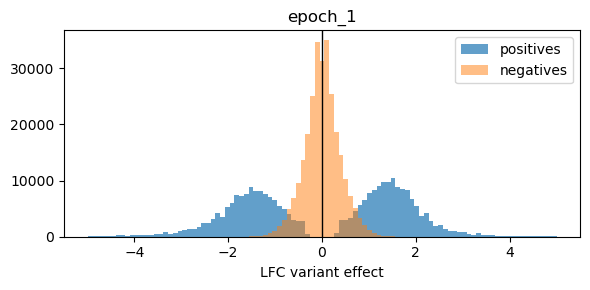

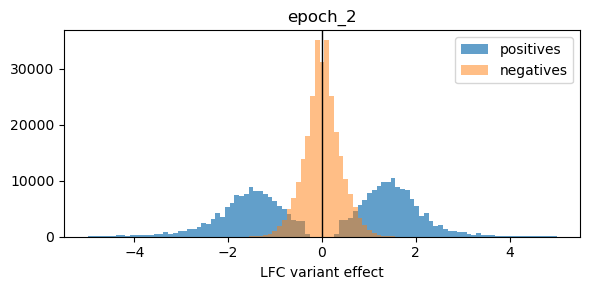

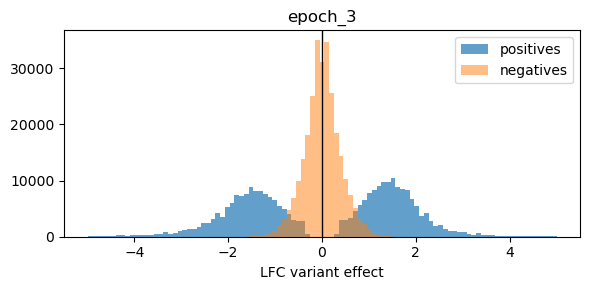

In [39]:
# ==================================================
# Sanity check histograms (match pandas)
# ==================================================
bins = np.linspace(-5, 5, 100)
for epoch, idx_dict in epoch_indices.items():
    logit = epoch_adata.layers[f"logit_es.{epoch}"]

    pos_rows, pos_cols = idx_dict["pos"]
    neg_rows, neg_cols = idx_dict["neg"]

    pos_vals = logit[pos_rows, pos_cols].A1
    neg_vals = logit[neg_rows, neg_cols].A1

    plt.figure(figsize=(6, 3))
    plt.hist(pos_vals, bins=bins, alpha=0.7, label="positives")
    plt.hist(neg_vals, bins=bins, alpha=0.5, label="negatives")
    plt.axvline(0, color="black", lw=1)
    plt.title(epoch)
    plt.xlabel("LFC variant effect")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [40]:
#bounds check
# ==================================================
print("\nRunning sanity checks...")
assert "epoch_names" in epoch_adata.uns
for epoch in epoch_adata.uns["epoch_names"]:
    for base in ["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"]:
        layer = f"{base}.{epoch}"
        assert layer in epoch_adata.layers, f"Missing {layer}"
        assert epoch_adata.layers[layer].shape == epoch_adata.shape
print("✔ All epoch layers present")
print("✔ Shapes consistent")
print("✔ Ready for training")


Running sanity checks...
✔ All epoch layers present
✔ Shapes consistent
✔ Ready for training


In [41]:
# Save
out_file = "/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_35totalcount_3epoch.h5ad"
epoch_adata.write_h5ad(out_file, compression="gzip")
print("Saved:", out_file)


Saved: /net/seq/data2/projects/mbrannon/vinson/3_9_dataset_35totalcount_3epoch.h5ad


In [ ]:
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/3_9_dataset_35totalcount_3epoch.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/home/mbrannon/genotype_no_multiallelic.tsv.gz \
/net/seq/data2/projects/mbrannon/variant_model_test \
--config /home/mbrannon/.local/src/vinson/train/variant/legnetMar6.yaml \
--sequence_model_checkpoint /home/mbrannon/.local/src/vinson/train/variant/legnetmar3.ckpt \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--epochs 15 \
--nodelist hpcg04-heavy 

In [ ]:
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/3_2_dataset.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/net/seq/data2/projects/mbrannon/all_phased.no_ambiguous.sorted.with_header.bgz \
/net/seq/data2/projects/mbrannon/variant_model_test \
--config /home/mbrannon/.local/src/vinson/train/variant/basset_embed.new_cluster.one_cycle_LR.yaml \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--nodelist hpcg04-heavy --debug